In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
or_threshold_pheno = 0.99
or_threshold_anno = 0.99

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
# existing_annos += ['five_prime_utr_variant_consequence_uaug_gained', 'five_prime_utr_variant_consequence_uaug_lost', 'five_prime_utr_variant_consequence_uframeshift', 'five_prime_utr_variant_consequence_ustop_gained', 'five_prime_utr_variant_consequence_ustop_lost']

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        filter_expression &
        (
            (pl.col('consequence_splice_donor_variant') == 0) &
            (pl.col('consequence_splice_acceptor_variant') == 0) &
            (pl.col('consequence_splice_region_variant') == 0) &
            (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
            (pl.col('consequence_splice_donor_region_variant') == 0) &
            (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        ) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

loftee_hc,esmscoremissense,absplice2_max,gpn_score,absplice_dna_max,id,delta_score,TSS,cadd_raw,promoterai_abs,promoterai,mamphylop,verphylop,Strand,gpn_star_llr_calibrated_mean,gene_length,region,pangolin_score,dist_to_tss,am_pathogenicity,gene_name,abexp_min
i8,f32,f32,f32,f32,str,f32,i64,f32,f32,f32,f32,f32,cat,f64,i64,str,f32,i64,f32,str,f64
0,0.0,0.000033,-1.5,0.001,"""chr2:169197167:T:G""",0.0,169362534,0.466688,0.0,0.0,0.774,0.217,"""-""",0.153293,235427,"""ENSG00000081479""",0.0,165367,0.0,"""LRP2""",-0.006063
0,0.0,0.000116,-0.63,0.003,"""chr2:169204292:A:T""",0.01,169362534,0.104863,0.0,0.0,0.085,0.291,"""-""",1.684965,235427,"""ENSG00000081479""",0.0,158242,0.0,"""LRP2""",-0.026342
0,0.0,0.000033,-1.64,0.001,"""chr2:169030531:C:T""",0.0,169031324,0.326902,0.0,0.0,0.015,0.023,"""-""",-1.212965,115828,"""ENSG00000073734""",0.0,793,0.0,"""ABCB11""",-0.005501
0,0.0,0.000033,0.08,0.001,"""chr2:169007174:C:T""",0.0,169031324,-0.070862,0.0,0.0,0.19,0.193,"""-""",-0.238119,115828,"""ENSG00000073734""",0.0,24150,0.0,"""ABCB11""",-0.005501
0,0.0,0.000033,-0.98,0.001,"""chr2:169175752:G:A""",0.0,169362534,0.211538,0.0,0.0,0.117,0.117,"""-""",-1.768037,235427,"""ENSG00000081479""",0.0,186782,0.0,"""LRP2""",-0.006358
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0.0,0.0,1.12,0.0,"""chr3:112365432:T:C""",0.0,112332346,-0.577349,0.0,0.0,-1.553,-1.497,"""+""",0.631638,30467,"""ENSG00000091972""",0.0,33086,0.0,"""CD200""",null
0,0.0,0.0,-4.13,0.0,"""chr3:112330089:T:G""",0.0,112332346,0.73253,0.0,0.0,-0.073,-0.052,"""+""",0.406711,30467,"""ENSG00000091972""",0.0,-2257,0.0,"""CD200""",null
0,0.0,0.0,-1.89,0.0,"""chr3:112329326:T:C""",0.0,112332346,0.636473,0.0,0.0,0.392,0.407,"""+""",-1.380881,30467,"""ENSG00000091972""",0.0,-3020,0.0,"""CD200""",null


In [4]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )
    .filter(
        pl.col('annotation_score_dircor_ptile') > or_threshold_anno
    )

    # Filter based on category
    .filter(
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:168983350:T:A""","""ENSG00000073734""","""cadd_raw""",1.59653,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,1.59653,36241.0,36474,0.993612
"""chr2:213104762:T:G""","""ENSG00000030419""","""cadd_raw""",2.790495,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,2.790495,47490.0,47903,0.991378
"""chr2:213056612:C:A""","""ENSG00000030419""","""cadd_raw""",2.999623,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,2.999623,47673.0,47903,0.995199
"""chr2:212535987:C:T""","""ENSG00000178568""","""cadd_raw""",2.477477,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,2.477477,426725.0,430035,0.992303
"""chr2:168985969:T:C""","""ENSG00000073734""","""cadd_raw""",2.775712,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,2.775712,36457.0,36474,0.999534
…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:21794752:T:G""","""ENSG00000171714""","""absplice2_max""",0.000239,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.000239,181896.0,183707,0.990142
"""chr10:32893628:C:T""","""ENSG00000150093""","""absplice2_max""",0.00131,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.00131,33947.0,34253,0.991066
"""chr20:3709046:C:A""","""ENSG00000088827""","""absplice2_max""",0.016415,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.016415,6149.0,6154,0.999188


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [7]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.col('mean_pheno_value_ptile') * pl.col('loftee_corr')
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i*(1-or_threshold_anno))/100 for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (pl.col("above_cutoff") &(pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)).sum(),
        n_notdis_above_cutoff = (pl.col("above_cutoff") & (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)).sum()
    )
    .with_columns(
        odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')
or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,f64
"""absplice_dna_max""","""ENSG00000101191""","""DIDO1""","""arm_fat_percentage_left_int""",0.99,0,100,0.990099
"""gpn_star_llr_calibrated_mean""","""ENSG00000138688""","""KIAA1109""","""arm_fatfree_mass_right_int""",0.99,0,379,0.263158
"""verphylop""","""ENSG00000119403""","""PHF19""","""arm_predicted_mass_left_int""",0.99,0,60,1.639344
"""delta_score""","""ENSG00000138685""","""FGF2""","""arm_predicted_mass_right_int""",0.99,0,102,0.970874
"""absplice2_max""","""ENSG00000138688""","""KIAA1109""","""body_mass_index_bmi_int""",0.99,0,393,0.253807
…,…,…,…,…,…,…,…
"""absplice_dna_max""","""ENSG00000100578""","""KIAA0586""","""whole_body_water_mass_int""",0.9999,0,2,33.333333
"""gpn_star_llr_calibrated_mean""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",0.9999,0,7,12.5
"""absplice2_max""","""ENSG00000163631""","""ALB""","""cholesterol_int""",0.9999,0,0,100.0


In [14]:
plt_df = (
    or_df
    .drop_nans()
    .with_columns(
        n_gene_phenos = pl.len().over(['ptile_cutoff', 'annotation']),
        med_odds_ratio = pl.col('odds_ratio').median().over(['ptile_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        std_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('std_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('std_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'std_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)
plt_df

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""gpn_star_llr_calibrated_mean""",0.99,1144,0.943396,3.566567,7.267922,17.811695,-10.678561,"""#942c80""","""GPN-Star"""
"""pangolin_score""",0.99,1116,0.836835,2.922171,5.462313,13.628305,-7.783962,"""#28a745""","""Pangolin"""
"""cadd_raw""",0.99,1144,0.813008,3.312551,7.003775,17.03995,-10.414847,"""#1f77b4""","""CADD Raw"""
"""absplice_dna_max""",0.99,1117,1.052632,3.488983,7.560317,18.307204,-11.329238,"""#28a745""","""AbSplice (max)"""
"""gpn_score""",0.99,1141,0.943396,3.26691,6.146614,15.314273,-8.780453,"""#942c80""","""GPN-MSA"""
…,…,…,…,…,…,…,…,…,…
"""verphylop""",0.9999,1138,50.0,48.616261,31.421608,110.202612,-12.97009,"""#942c80""","""Vertebrate PhyloP"""
"""pangolin_score""",0.9999,1116,33.333333,44.703661,27.736122,99.06646,-9.659138,"""#28a745""","""Pangolin"""
"""gpn_star_llr_calibrated_mean""",0.9999,1144,50.0,47.29359,28.518187,103.189236,-8.602056,"""#942c80""","""GPN-Star"""


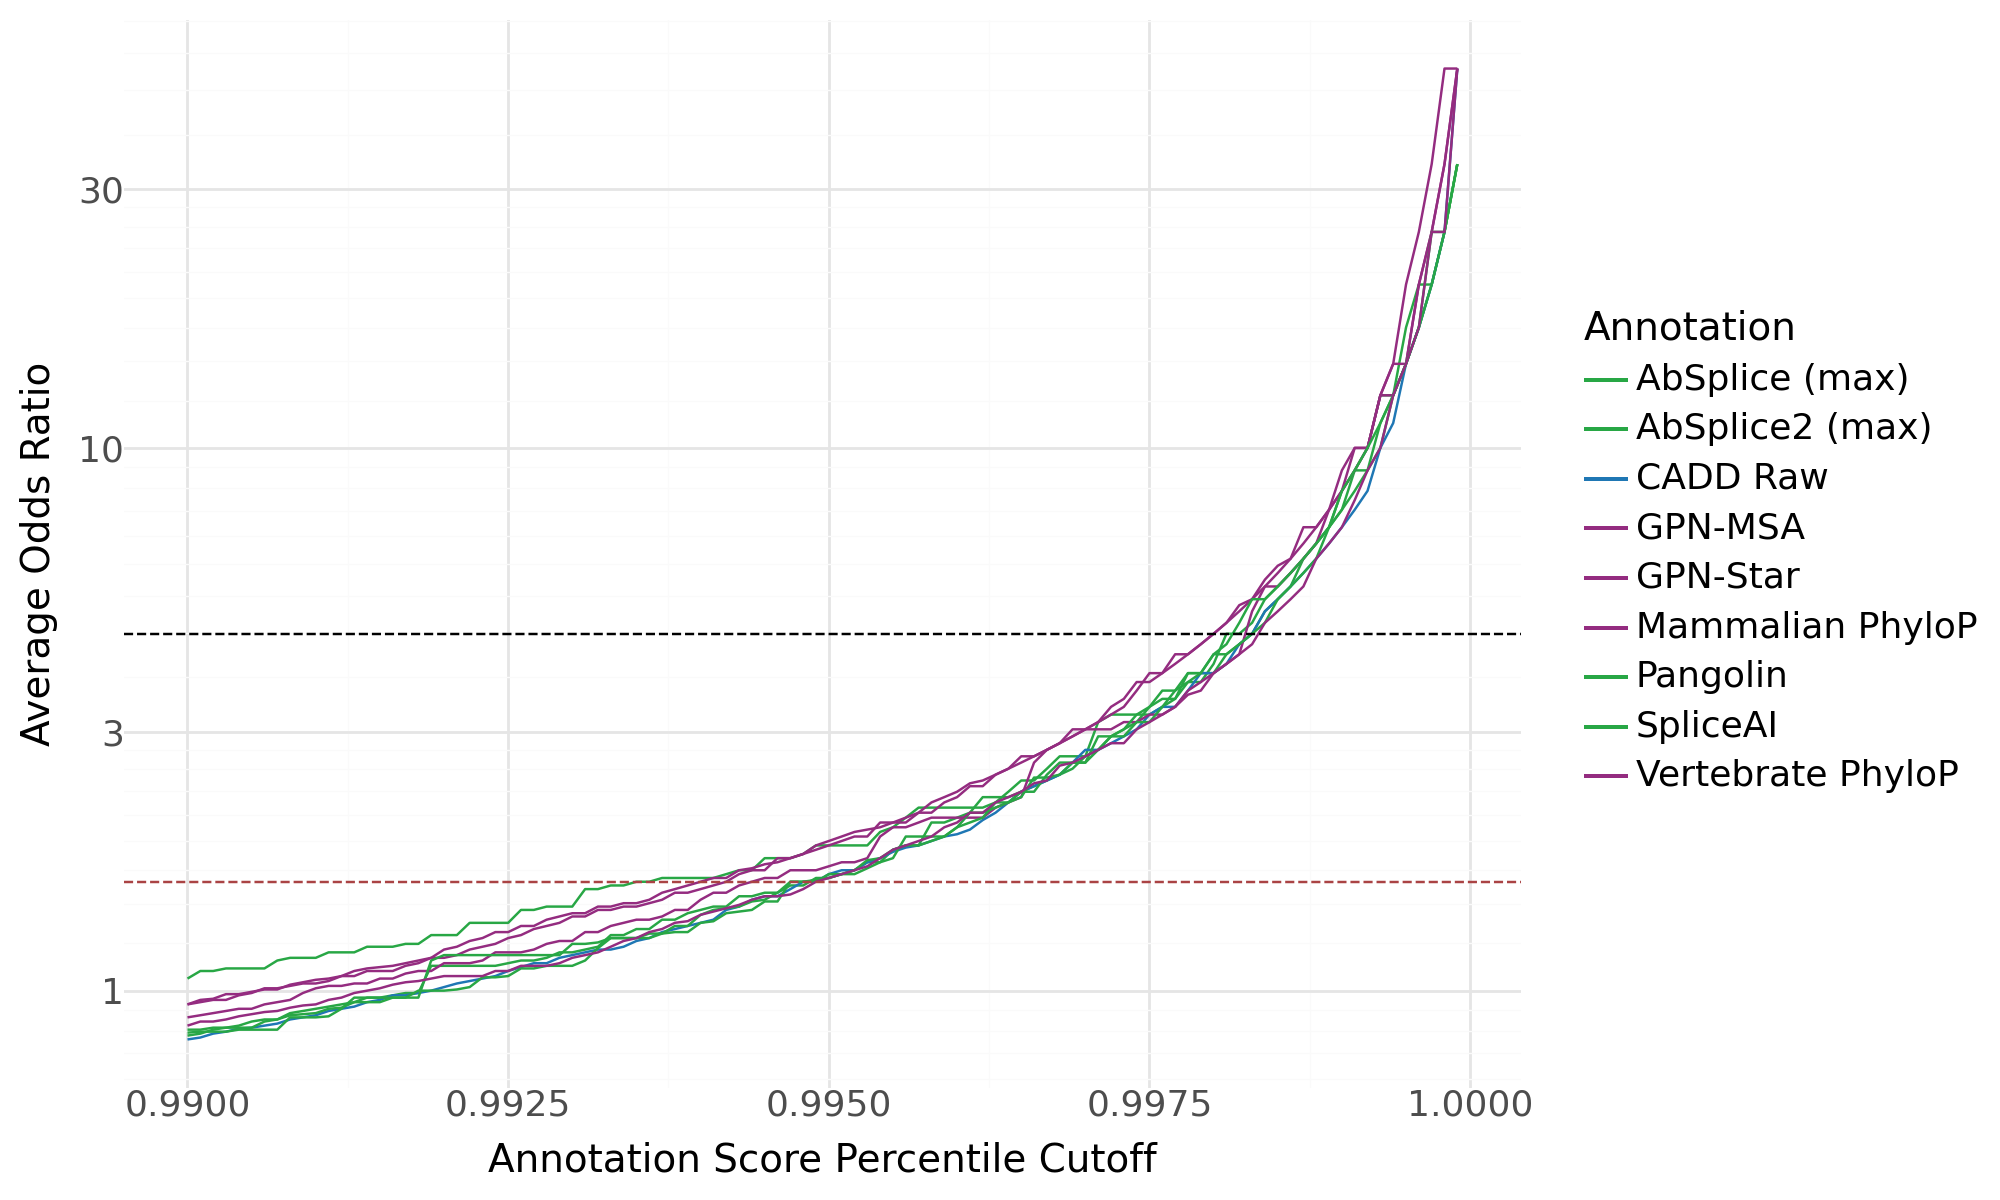

In [16]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

# Odds ratio for LOFTEE:
# mean: 6.735885
# median: 4.545455

# Odds ratio for AM>0.8:
# mean: 8.966652
# median: 1.587302

am_lof_or_mean = {
    'loftee': 6.735885,
    'am': 8.966652
}

am_lof_or_median = {
    'loftee': 4.545455,
    'am': 1.587302
}

(
    ggplot(
        plt_df,
        # aes(x='ptile_cutoff', y='avg_odds_ratio', color='label')
        aes(x='ptile_cutoff', y='med_odds_ratio', color='label')
    )
    + geom_line()
    # + geom_hline(aes(yintercept=am_lof_or_mean['loftee']), linetype='dashed', color='black')
    # + geom_hline(aes(yintercept=am_lof_or_mean['am']), linetype='dashed', color='#AA4344')
    + geom_hline(aes(yintercept=am_lof_or_median['loftee']), linetype='dashed', color='black')
    + geom_hline(aes(yintercept=am_lof_or_median['am']), linetype='dashed', color='#AA4344')
    # + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.2)
    # + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio",
        x="Annotation Score Percentile Cutoff",
        color="Annotation",
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=14),
        legend_text=element_text(size=13),
        legend_title=element_text(size=14),
    )
)

In [11]:
plt_df.filter(pl.col('ptile_cutoff') == 0.9999).sort('avg_odds_ratio', descending=True)

annotation,ptile_cutoff,n_gene_phenos,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,str,str
"""mamphylop""",0.9999,1137,66.442999,33.940299,132.965985,-0.079987,"""#942c80""","""Mammalian PhyloP"""
"""verphylop""",0.9999,1138,48.616261,31.421608,110.202612,-12.97009,"""#942c80""","""Vertebrate PhyloP"""
"""gpn_star_llr_calibrated_mean""",0.9999,1144,47.29359,28.518187,103.189236,-8.602056,"""#942c80""","""GPN-Star"""
"""gpn_score""",0.9999,1141,46.399792,26.79529,98.91856,-6.118976,"""#942c80""","""GPN-MSA"""
"""absplice_dna_max""",0.9999,1117,46.053178,27.917951,100.772362,-8.666007,"""#28a745""","""AbSplice (max)"""
"""absplice2_max""",0.9999,1123,44.947108,27.672808,99.185812,-9.291595,"""#28a745""","""AbSplice2 (max)"""
"""pangolin_score""",0.9999,1116,44.703661,27.736122,99.06646,-9.659138,"""#28a745""","""Pangolin"""
"""cadd_raw""",0.9999,1144,43.897705,25.954149,94.767837,-6.972427,"""#1f77b4""","""CADD Raw"""
"""delta_score""",0.9999,1116,43.377289,26.199187,94.727697,-7.973118,"""#28a745""","""SpliceAI"""


In [31]:
plt_df.filter(pl.col('avg_odds_ratio') >= 6.735885).head(9).sort('avg_odds_ratio')

annotation,ptile_cutoff,n_gene_phenos,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,str,str
"""absplice_dna_max""",0.9955,1120,6.737679,14.635039,35.422354,-21.946997,"""#28a745""","""AbSplice (max)"""
"""mamphylop""",0.996,1141,6.755815,13.029806,32.294234,-18.782604,"""#942c80""","""Mammalian PhyloP"""
"""absplice2_max""",0.9961,1120,6.793035,13.209719,32.684085,-19.098015,"""#28a745""","""AbSplice2 (max)"""
"""absplice_dna_max""",0.9956,1120,6.847468,14.710669,35.680379,-21.985443,"""#28a745""","""AbSplice (max)"""
"""mamphylop""",0.9961,1141,6.859567,13.125303,32.58516,-18.866026,"""#942c80""","""Mammalian PhyloP"""
"""absplice_dna_max""",0.9957,1120,6.965071,14.932322,36.232421,-22.30228,"""#28a745""","""AbSplice (max)"""
"""absplice_dna_max""",0.9958,1120,7.025477,14.931202,36.290633,-22.23968,"""#28a745""","""AbSplice (max)"""
"""absplice_dna_max""",0.9959,1120,7.077452,14.93512,36.350286,-22.195383,"""#28a745""","""AbSplice (max)"""
"""absplice_dna_max""",0.996,1120,7.241438,15.105478,36.848174,-22.365298,"""#28a745""","""AbSplice (max)"""


In [32]:
anno['id'].n_unique() * (1-0.9955)

83793.55049999904